<a href="https://colab.research.google.com/github/sevval-345/SoftITo/blob/main/logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

:::
# Lojistik Regresyon Algoritması

**Veri Seti:** heart.csv — Kalp hastalığı tahmini

---

## 1. Konu Anlatımı — Lojistik Regresyon Nedir?

Lojistik regresyon, **sınıflandırma** problemleri için kullanılan bir makine öğrenmesi algoritmasıdır. Adında "regresyon" geçmesine rağmen aslında bir sınıflandırma yöntemidir.

### 1.1. Temel Mantık
Lineer regresyonda çıktı sürekli bir değer iken (ör: ev fiyatı), lojistik regresyonda çıktı kategoriktir (ör: hasta/sağlıklı). Lojistik regresyon, bir veri noktasının belirli bir sınıfa ait olma **olasılığını** hesaplar.

### 1.2. Sigmoid (Lojistik) Fonksiyonu

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

Bu fonksiyon herhangi bir gerçel sayıyı 0 ile 1 arasına sıkıştırır:
- $z \to +\infty \Rightarrow \sigma(z) \to 1$
- $z \to -\infty \Rightarrow \sigma(z) \to 0$
- $z = 0 \Rightarrow \sigma(z) = 0.5$

$z$ değeri lineer bir kombinasyondur:
$$z = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + ... + \beta_n x_n$$

### 1.3. Karar Sınırı (Decision Boundary)
- $\sigma(z) \geq 0.5 \rightarrow$ sınıf 1 (hastalık var)
- $\sigma(z) < 0.5 \rightarrow$ sınıf 0 (hastalık yok)

### 1.4. Maliyet Fonksiyonu (Cross-Entropy Loss)
$$J(\beta) = -\frac{1}{m} \sum{\big[ y \log(\hat{y}) + (1 - y) \log(1 - \hat{y}) \big]}$$

### 1.5. Gradient Descent
$$\beta_j = \beta_j - \alpha \frac{\partial J}{\partial \beta_j}$$

## 2. Gerekli Kütüphaneler

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score
)

plt.rcParams['figure.dpi'] = 150

## 3. Veriyi Yükleme ve Keşfetme

In [4]:
df = pd.read_csv("/content/heart.csv")

print(f"Veri seti boyutu: {df.shape[0]} satır, {df.shape[1]} sütun")
print(f"\nSütun isimleri:\n{', '.join(df.columns.tolist())}")
print(f"\nSınıf dağılımı (target):")
print(df['target'].value_counts().to_string())
print(f"\nİlk 5 satır:")
display(df.head())
print(f"\nVeri seti istatistikleri:")
display(df.describe())
print(f"\nEksik veri kontrolü:")
print(df.isnull().sum().to_string())

Veri seti boyutu: 1025 satır, 14 sütun

Sütun isimleri:
age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal, target

Sınıf dağılımı (target):
target
1    526
0    499

İlk 5 satır:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0



Veri seti istatistikleri:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000



Eksik veri kontrolü:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0


## 4. Özellik ve Hedef Ayırma

In [5]:
X = df.drop("target", axis=1)
y = df["target"]

print(f"Özellik matrisi (X): {X.shape}")
print(f"Hedef vektör (y):   {y.shape}")
print(f"\nÖzellikler: {X.columns.tolist()}")

Özellik matrisi (X): (1025, 13)
Hedef vektör (y):   (1025,)

Özellikler: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


## 5. Eğitim/Test Ayrımı

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Eğitim seti: {X_train.shape[0]} örnek")
print(f"Test seti:   {X_test.shape[0]} örnek")
print(f"\nEğitim seti sınıf dağılımı:\n{y_train.value_counts().to_string()}")
print(f"\nTest seti sınıf dağılımı:\n{y_test.value_counts().to_string()}")

Eğitim seti: 820 örnek
Test seti:   205 örnek

Eğitim seti sınıf dağılımı:
target
1    421
0    399

Test seti sınıf dağılımı:
target
1    105
0    100


## 6. Özellik Ölçeklendirme (Standardizasyon)

Lojistik regresyon gradyan inişi kullandığı için özelliklerin aynı ölçekte olması önemlidir.

In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Özellikler standardize edildi (mean=0, std=1)")
print(f"\nEğitim seti ilk satır (ölçeklenmiş):")
print(np.round(X_train_scaled[0], 3))

Özellikler standardize edildi (mean=0, std=1)

Eğitim seti ilk satır (ölçeklenmiş):
[ 0.812 -1.51  -0.91   0.315  0.896  2.347  0.927 -1.921 -0.718  0.697
 -0.598  2.207 -0.562]


## 7. Lojistik Regresyon Modeli Eğitimi

Scikit-learn'in `LogisticRegression` sınıfını kullanıyoruz.
- `penalty='l2'`: L2 regularization (overfitting'i önler)
- `C=1.0`: Regularizasyon şiddetinin tersi (küçük C = güçlü regularizasyon)
- `solver='lbfgs'`: Optimizasyon algoritması
- `max_iter=1000`: Maksimum iterasyon sayısı

In [8]:
model = LogisticRegression(
    penalty='l2', C=1.0, solver='lbfgs', max_iter=1000, random_state=42
)
model.fit(X_train_scaled, y_train)
print("Model eğitimi tamamlandı.")

Model eğitimi tamamlandı.


In [9]:
# Model katsayıları
print(f"Kesişim (bias - β₀): {model.intercept_[0]:.4f}")
print(f"\nKatsayılar (β₁ ... βₙ):")
coef_df = pd.DataFrame({
    'Özellik': X.columns,
    'Katsayı': model.coef_[0],
    '|Katsayı|': np.abs(model.coef_[0])
}).sort_values('|Katsayı|', ascending=False)
display(coef_df)

Kesişim (bias - β₀): -0.1140

Katsayılar (β₁ ... βₙ):


,Özellik,Katsayı,|Katsayı|
2,cp,0.867769,0.867769
1,sex,-0.781747,0.781747
11,ca,-0.745506,0.745506
9,oldpeak,-0.614295,0.614295
8,exang,-0.517055,0.517055
12,thal,-0.499174,0.499174
7,thalach,0.411778,0.411778
10,slope,0.365533,0.365533
3,trestbps,-0.362392,0.362392
4,chol,-0.275126,0.275126


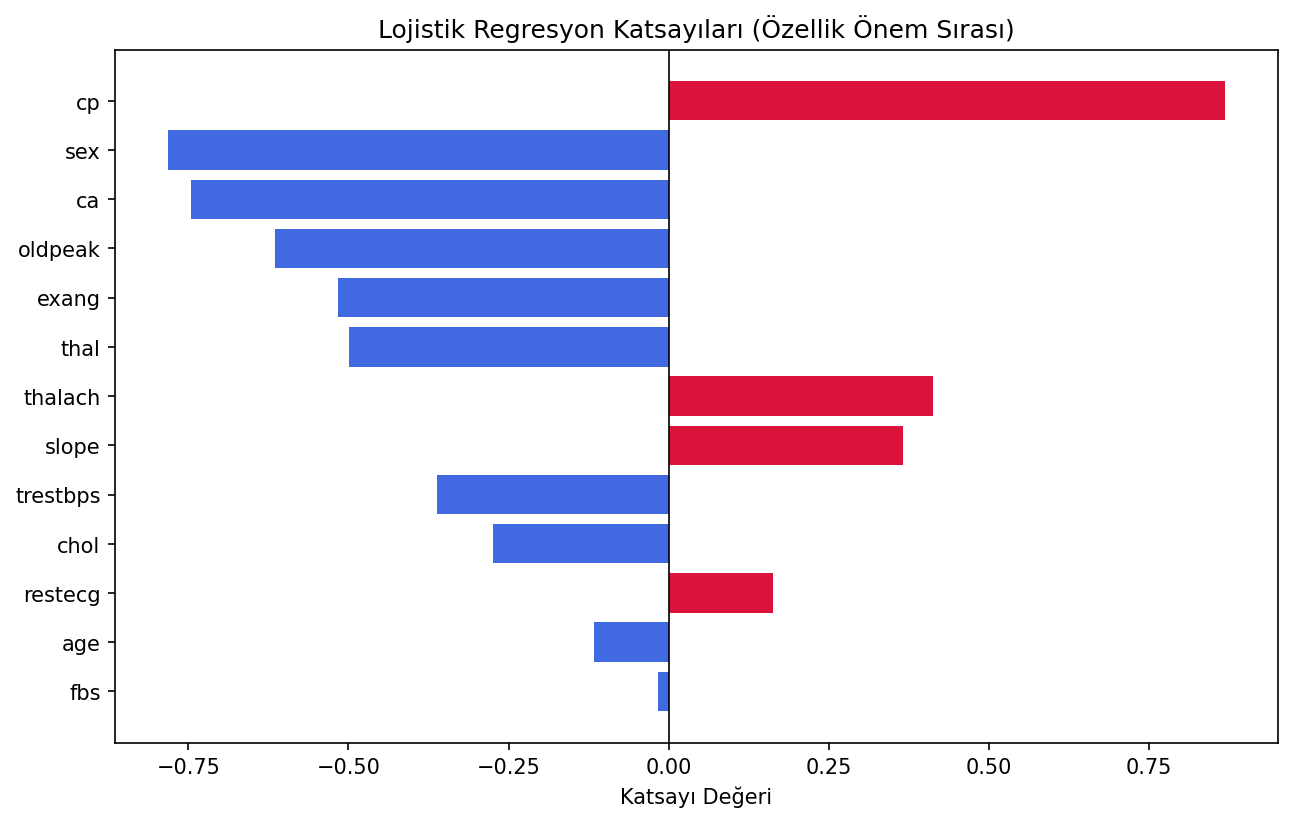

In [10]:
# Özellik önem sıralaması görselleştirmesi
plt.figure(figsize=(10, 6))
colors = ['crimson' if c > 0 else 'royalblue' for c in coef_df['Katsayı']]
plt.barh(coef_df['Özellik'], coef_df['Katsayı'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Katsayı Değeri')
plt.title('Lojistik Regresyon Katsayıları (Özellik Önem Sırası)')
plt.gca().invert_yaxis()
plt.show()

## 8. Model Değerlendirme

In [11]:
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc_roc = roc_auc_score(y_test, y_pred_proba)

print("=== MODEL PERFORMANS METRİKLERİ ===")
print(f"  Doğruluk (Accuracy):     {accuracy:.4f}  ({(accuracy*100):.2f}%)")
print(f"  Hassasiyet (Precision):  {precision:.4f}  ({(precision*100):.2f}%)")
print(f"  Duyarlılık (Recall):     {recall:.4f}  ({(recall*100):.2f}%)")
print(f"  F1-Skoru:                {f1:.4f}")
print(f"  AUC-ROC:                 {auc_roc:.4f}")

=== MODEL PERFORMANS METRİKLERİ ===
  Doğruluk (Accuracy):     0.8098  (80.98%)
  Hassasiyet (Precision):  0.7619  (76.19%)
  Duyarlılık (Recall):     0.9143  (91.43%)
  F1-Skoru:                0.8312
  AUC-ROC:                 0.9298


In [12]:
# Karmaşıklık Matrisi
cm = confusion_matrix(y_test, y_pred)

print("=== KARIŞIKLIK MATRİSİ (Confusion Matrix) ===")
print(f"               Tahmin: 0    Tahmin: 1")
print(f"  Gerçek: 0     {cm[0,0]:3d} (TN)       {cm[0,1]:3d} (FP)")
print(f"  Gerçek: 1     {cm[1,0]:3d} (FN)       {cm[1,1]:3d} (TP)")
print()
print("=== SINIFLANDIRMA RAPORU ===")
print(classification_report(y_test, y_pred, target_names=["Hastalık Yok", "Hastalık Var"]))

=== KARIŞIKLIK MATRİSİ (Confusion Matrix) ===
               Tahmin: 0    Tahmin: 1
  Gerçek: 0      70 (TN)        30 (FP)
  Gerçek: 1       9 (FN)        96 (TP)

=== SINIFLANDIRMA RAPORU ===
              precision    recall  f1-score   support

Hastalık Yok       0.89      0.70      0.78       100
Hastalık Var       0.76      0.91      0.83       105

    accuracy                           0.81       205
   macro avg       0.82      0.81      0.81       205
weighted avg       0.82      0.81      0.81       205



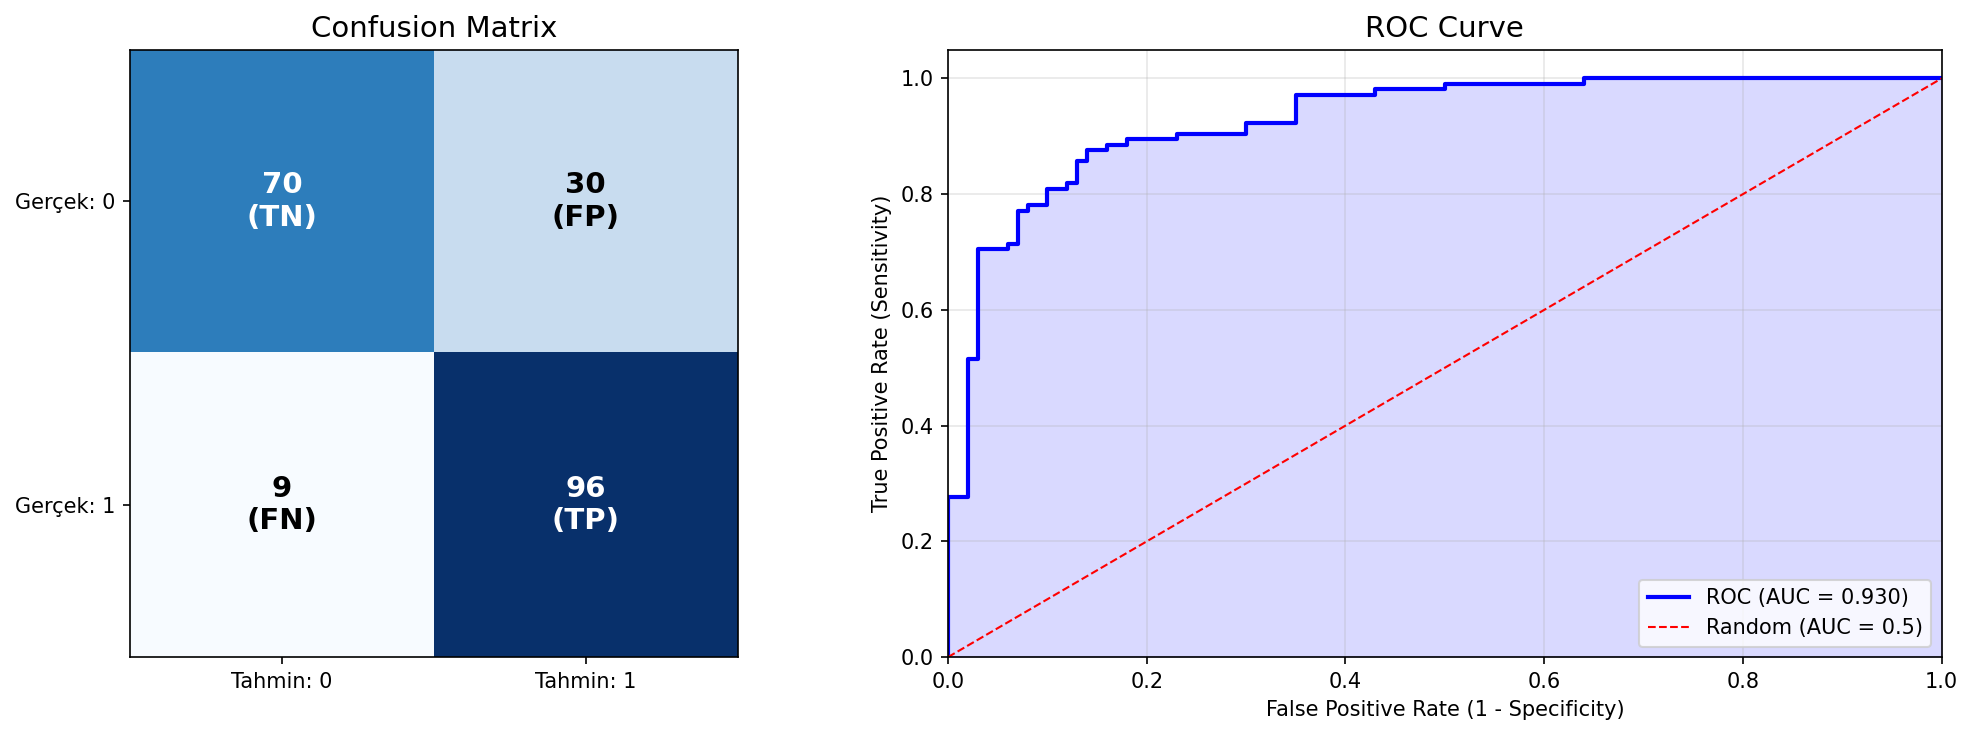

In [13]:
# Karmaşıklık Matrisi Görselleştirme
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix heatmap
im = ax[0].imshow(cm, cmap='Blues')
ax[0].set_xticks([0, 1])
ax[0].set_yticks([0, 1])
ax[0].set_xticklabels(['Tahmin: 0', 'Tahmin: 1'])
ax[0].set_yticklabels(['Gerçek: 0', 'Gerçek: 1'])
for i in range(2):
    for j in range(2):
        ax[0].text(j, i, f'{cm[i, j]}\n({"TP" if i==1 and j==1 else "TN" if i==0 and j==0 else "FP" if i==0 and j==1 else "FN"})',
                 ha='center', va='center', fontsize=14, fontweight='bold',
                 color='white' if cm[i, j] > cm.max()/2 else 'black')
ax[0].set_title('Confusion Matrix', fontsize=14)

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
ax[1].plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC (AUC = {auc_roc:.3f})')
ax[1].plot([0, 1], [0, 1], 'r--', linewidth=1, label='Random (AUC = 0.5)')
ax[1].fill_between(fpr, tpr, alpha=0.15, color='blue')
ax[1].set_xlim([0.0, 1.0])
ax[1].set_ylim([0.0, 1.05])
ax[1].set_xlabel('False Positive Rate (1 - Specificity)')
ax[1].set_ylabel('True Positive Rate (Sensitivity)')
ax[1].set_title('ROC Curve', fontsize=14)
ax[1].legend(loc='lower right')
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Örnek Tahmin

In [15]:
sample = X_test.iloc[0:1]
sample_scaled = scaler.transform(sample)
sample_proba = model.predict_proba(sample_scaled)[0, 1]
sample_pred = model.predict(sample_scaled)[0]

print("Örnek hasta verisi:")
display(sample)
print(f"\nHastalık olasılığı: {sample_proba:.4f} ({sample_proba*100:.1f}%)")
print(f"Tahmin: {sample_pred} ({'Hastalık Var' if sample_pred == 1 else 'Hastalık Yok'})")
print(f"Gerçek: {y_test.iloc[0]}")

Örnek hasta verisi:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
756,64,1,0,120,246,0,0,96,1,2.2,0,1,2



Hastalık olasılığı: 0.0119 (1.2%)
Tahmin: 0 (Hastalık Yok)
Gerçek: 0


## 10. Sonuç

**En etkili özellikler:** `cp` (göğüs ağrısı tipi), `sex` (cinsiyet), `ca` (renkli damar sayısı)

### Önemli Kavramların Özeti
1. **Sigmoid fonksiyonu**: Lineer çıktıyı 0-1 arası olasılığa dönüştürür
2. **Karar sınırı**: σ(z) = 0.5 eşiği ile sınıflandırma yapılır
3. **Cross-Entropy loss**: Modelin ne kadar yanıldığını ölçer
4. **Gradient Descent**: Ağırlıkları optimize etmek için kullanılır
5. **AUC-ROC**: Modelin tüm eşik değerlerindeki performansını ölçer

In [16]:
print("=== SONUÇ TABLOSU ===")
print(f"  Doğruluk (Accuracy):     {accuracy:.4f}  ({(accuracy*100):.2f}%)")
print(f"  Hassasiyet (Precision):  {precision:.4f}  ({(precision*100):.2f}%)")
print(f"  Duyarlılık (Recall):     {recall:.4f}  ({(recall*100):.2f}%)")
print(f"  F1-Skoru:                {f1:.4f}")
print(f"  AUC-ROC:                 {auc_roc:.4f}")

=== SONUÇ TABLOSU ===
  Doğruluk (Accuracy):     0.8098  (80.98%)
  Hassasiyet (Precision):  0.7619  (76.19%)
  Duyarlılık (Recall):     0.9143  (91.43%)
  F1-Skoru:                0.8312
  AUC-ROC:                 0.9298
